**Cell 1: Environment Setup and Library Imports**

 To begin the classification task, we import the necessary Python libraries. We rely on Pandas for data handling, Seaborn for visualizing distributions, and Scikit-Learn for the entire machine learning pipeline. This includes tools for data splitting, preprocessing (scaling and encoding), model building (Neural Networks and Classical models), and performance evaluation (Precision, Recall, F1-Score).



In [19]:
# ================================
# 1. Imports
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning Tools
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import SelectKBest, f_classif

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
print("Libraries and tools initialized.")
uploaded = files.upload()


Libraries and tools initialized.


Saving diabetes_dataset.csv to diabetes_dataset (1).csv


**Cell 2: Dataset Selection and SDG Alignment**

  We have selected the Diabetes Dataset for this project. This choice aligns directly with UNSDG 3: Good Health and Well-being, specifically Target 3.4, which aims to reduce premature mortality from non-communicable diseases. The objective is to predict the binary target variable diagnosed_diabetes (0 or 1) based on lifestyle and physiological attributes. We remove columns like diabetes_stage and diabetes_risk_score as they are direct indicators of the target (data leakage) and would prevent the model from learning real patterns.

In [25]:

# 2. Load Data and Remove Leakage
df_diabetes = pd.read_csv('diabetes_dataset.csv')

# Preventing Data Leakage:
# We drop 'diabetes_stage' and 'diabetes_risk_score' because they directly reveal the diagnosis.
df_diabetes.drop(['diabetes_stage', 'diabetes_risk_score'], axis=1, inplace=True)

# Dataset Overview
print(f"Dataset Shape: {df_diabetes.shape}")
print("Target: diagnosed_diabetes")
df_diabetes.head()

Dataset Shape: (100000, 29)
Target: diagnosed_diabetes


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,68,239,41,160,145,136,236,6.36,8.18,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,67,116,55,50,30,93,150,2.00,5.63,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,74,213,66,99,36,118,195,5.07,7.51,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,68,171,50,79,140,139,253,5.28,9.03,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,67,210,52,125,160,137,184,12.74,7.20,1


**Cell 3: Exploratory Data Analysis (EDA)**

  Understanding the balance of our target class is crucial. If the dataset is heavily skewed (e.g., 90% healthy, 10% diabetic), the model might simply guess "healthy" every time. We visualize the count of diagnosed vs. undiagnosed patients. Additionally, we check the dataset for any missing values or inconsistencies that might disrupt the training process.

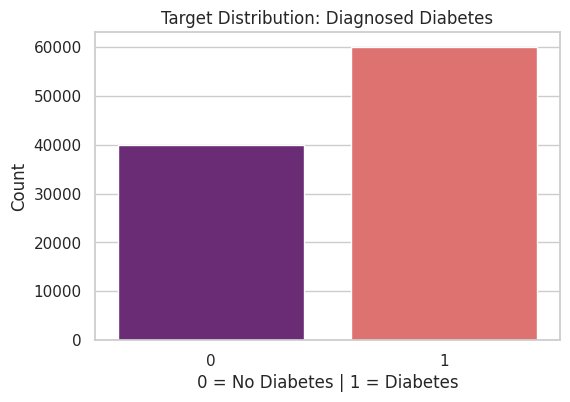

Missing Values per Column:
0


In [26]:
# 3. EDA: Class Balance Visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosed_diabetes', data=df_diabetes, palette='magma')
plt.title("Target Distribution: Diagnosed Diabetes")
plt.xlabel("0 = No Diabetes | 1 = Diabetes")
plt.ylabel("Count")
plt.show()

# Check for missing values
print("Missing Values per Column:")
print(df_diabetes.isnull().sum().sum())

**Cell 4: Preprocessing (Encoding and Splitting)**

 The dataset contains categorical variables such as gender, ethnicity, and smoking_status. Machine learning models require numerical input, so we apply Label Encoding to convert these text labels into numbers. We then split the dataset into Training (80%) and Testing (20%) sets. Crucially, we use stratify=y during the split to ensure that the proportion of diabetic patients remains the same in both the training and testing sets.

In [27]:
# 4. Encoding and Splitting
# Encode Categorical Variables
cat_cols = ['gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status']
le = LabelEncoder()

for col in cat_cols:
    df_diabetes[col] = le.fit_transform(df_diabetes[col].astype(str))

# Sampling 10,000 rows for efficient processing in Colab
df_clf_sample = df_diabetes.sample(10000, random_state=42)
X = df_clf_sample.drop('diagnosed_diabetes', axis=1)
y = df_clf_sample['diagnosed_diabetes']

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Feature Scaling (Crucial for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data encoded, split, and scaled.")

Data encoded, split, and scaled.


**Cell 5: Building the Neural Network (MLP)**

  We design a Multi-Layer Perceptron (MLP) classifier. This neural network architecture consists of two hidden layers with 32 and 16 neurons, respectively. We utilize the 'tanh' activation function to capture non-linear relationships in the health data and the Adam optimizer for efficient weight adjustment. This model attempts to mimic biological neural processing to classify patients based on their complex health profiles.

In [28]:
# 5. Neural Network (MLP Classifier)
mlp_clf = MLPClassifier(hidden_layer_sizes=(32, 16),
                        activation='tanh',
                        solver='adam',
                        max_iter=300,
                        random_state=42)

mlp_clf.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_clf.predict(X_test_scaled)

print("Neural Network trained.")
print(classification_report(y_test, y_pred_mlp))

Neural Network trained.
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       810
           1       0.88      0.86      0.87      1190

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



**Cell 6: Classical Models & Hyperparameter Tuning**

To provide a robust comparison, we implement two classical algorithms: Logistic Regression and Random Forest. We apply GridSearchCV to the Logistic Regression model to find the optimal regularization parameter (C). This helps prevent overfitting. The Random Forest is used as an ensemble method, which generally provides high accuracy on tabular data by combining multiple decision trees.

In [29]:
# 6. Classical Models and Tuning
# Model A: Logistic Regression with Grid Search
param_grid = {'C': [0.1, 1, 10]}
grid_log = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=3, scoring='f1')
grid_log.fit(X_train_scaled, y_train)

# Model B: Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_scaled, y_train)

print(f"Best Logistic Regression Params: {grid_log.best_params_}")
print("Classical models trained.")

Best Logistic Regression Params: {'C': 0.1}
Classical models trained.


**Cell 7: Feature Selection and Final Evaluation**

 In this final step, we investigate which features are most important using SelectKBest (Filter Method). We select the top 10 features based on the ANOVA F-value. Finally, we compile a comparative table (as required by the project guidelines) showing the Accuracy, Precision, Recall, and F1-Score for the Neural Network, Optimized Logistic Regression, and Random Forest. This allows us to conclude which model is best suited for clinical deployment.

Top 10 Features: ['age', 'physical_activity_minutes_per_week', 'family_history_diabetes', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'ldl_cholesterol', 'glucose_fasting', 'glucose_postprandial', 'hba1c']

--- FINAL CLASSIFICATION RESULTS ---


,Model,Accuracy,Precision,Recall,F1-Score
0,Neural Network (MLP),0.8420,0.876076,0.855462,0.865646
1,Logistic Regression (Tuned),0.8460,0.862069,0.882353,0.872093
2,Random Forest,0.9105,1.000000,0.849580,0.918673


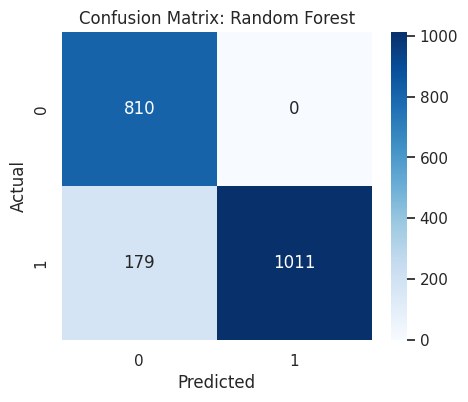

In [30]:
# 7. Feature Selection and Comparison Table
# Identify Top 10 Features
selector = SelectKBest(f_classif, k=10)
selector.fit(X_train, y_train)
top_features = X.columns[selector.get_support()]
print(f"Top 10 Features: {list(top_features)}")

# Metric Gathering Function
def get_metrics(model, X_set, y_set, name):
    preds = model.predict(X_set)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_set, preds),
        "Precision": precision_score(y_set, preds),
        "Recall": recall_score(y_set, preds),
        "F1-Score": f1_score(y_set, preds)
    }

# Compilation
results = [
    get_metrics(mlp_clf, X_test_scaled, y_test, "Neural Network (MLP)"),
    get_metrics(grid_log.best_estimator_, X_test_scaled, y_test, "Logistic Regression (Tuned)"),
    get_metrics(rf_clf, X_test_scaled, y_test, "Random Forest")
]

final_df = pd.DataFrame(results)
print("\n--- FINAL CLASSIFICATION RESULTS ---")
display(final_df)

# Confusion Matrix for the best model (Likely Random Forest)
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, rf_clf.predict(X_test_scaled)), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()